# 001. 注意機構(Attention Mechanism)

**Scaled Dot-Product Attention から Multi-Head Attention まで**
*From Scaled Dot-Product Attention to Multi-Head Attention*

`theories/01_foundations/001_attention_mechanism.ipynb`

## 1. 概要 / Overview

Transformer の中核である **注意機構(Attention Mechanism)** は、系列中の各位置が「他のどの位置の情報をどれだけ参照するか」を、内容そのものから動的に決める仕組みである。本ノートブックでは Vaswani et al. (2017) の **Scaled Dot-Product Attention** (スケール付き内積注意)を起点に、その素直な拡張である **Multi-Head Attention** (多頭注意)までを扱う。

具体的には、(1) Query / Key / Value(クエリ・キー・バリュー)という定式化とスケーリング係数 $\sqrt{d_k}$ の必要性を数式で導出し、(2) PyTorch でスクラッチ実装し(`nn.MultiheadAttention`などの既存実装は使わない)、(3) Attention 重みの可視化と簡単な系列復元タスク(copy task)の学習を通して、その挙動を実験的に確認する。

RNN・CNN との比較や、Seq2Seq 時代の Attention(Bahdanau / Luong)の歴史的経緯には深入りせず、**Transformer 論文の定式化を出発点** とする。

## 2. 参考論文 / References

| # | 著者 / Authors | タイトル / Title | 会議・媒体 / Venue | URL |
|---|---|---|---|---|
| [1] | Vaswani, Shazeer, Parmar, Uszkoreit, Jones, Gomez, Kaiser, Polosukhin | Attention Is All You Need | NeurIPS 2017 | https://arxiv.org/abs/1706.03762 |
| [2] | Clark, Khandelwal, Levy, Manning | What Does BERT Look At? An Analysis of BERT's Attention | BlackboxNLP @ ACL 2019 | https://arxiv.org/abs/1906.04341 |
| [3] | Elhage, Nanda, Olsson, et al. | A Mathematical Framework for Transformer Circuits | Transformer Circuits Thread, 2021 | https://transformer-circuits.pub/2021/framework/index.html |

- **[1] が本トピックの原典**。Scaled Dot-Product Attention(3.2.1 節)と Multi-Head Attention(3.2.2 節)、およびスケーリング係数 $1/\sqrt{d_k}$ の根拠(3.2.1 節の脚注)はすべてこの論文に基づく。
- [2] は学習済みモデルの Attention 重みを可視化・分析した研究で、本ノートブックの実験 2(ヒートマップの読み方)の背景として参照する。
- [3] は Attention を「QK 回路(どこを見るか)」と「OV 回路(何を書き込むか)」に分解して読む視点を与える。実験 3 の考察で参照する。

## 3. 理論 / Theory

### 3.1 動機・課題 / Motivation

自然言語のような系列データでは、離れた位置どうしが強く依存し合う(**長距離依存関係 / long-range dependency**)。例えば "**The dog** that chased the cat across the yard **was** tired." では、動詞 *was* の数一致は 6 語以上離れた *dog* に依存する。

系列モデルがこの依存を学習できるかは、**2 つの位置の間で情報が伝わる経路の長さ(path length)** に大きく左右される。経路が長いほど、逆伝播で勾配が減衰・発散しやすく、依存関係の学習が難しくなる。

| モデル | 任意の 2 位置間の最大経路長 | 系列方向の並列化 | 1 層の計算量 |
|---|---|---|---|
| RNN(LSTM / GRU) | $O(n)$ | 不可(逐次計算) | $O(n \cdot d^2)$ |
| CNN(カーネル幅 $k$) | $O(n / k)$(積層で $O(\log_k n)$) | 可 | $O(k \cdot n \cdot d^2)$ |
| **Self-Attention** | $O(1)$ | 可 | $O(n^2 \cdot d)$ |

($n$: 系列長、$d$: 表現次元。この比較は [1] Table 1 に対応する。)

RNN は時刻 $t$ の隠れ状態を $h_t = f(h_{t-1}, x_t)$ と逐次的に計算するため、(a) 任意の 2 位置間の経路長が距離に比例して伸び、(b) 系列方向に並列化できない、という 2 つの問題を同時に抱える。

**Attention はこの経路長を距離によらず $O(1)$ にする。** 各位置は他のすべての位置を 1 回の行列積で直接参照でき、しかもその計算は位置方向に完全並列である。代償として計算量・メモリが系列長の 2 乗 $O(n^2)$ になる(この計算量の緩和は後のトピック、例えば Flash Attention や線形注意で扱う)。

さらに重要なのは、**どこを参照するかが固定の重みではなく、入力内容から動的に決まる** 点である。畳み込みの重みは「相対位置」に紐づく静的なパラメータだが、Attention の重みは Query と Key の内容の類似度から毎回計算される **データ依存の重み(content-based addressing)** である。

### 3.2 Query, Key, Value

Attention は **連想記憶(associative memory)/ 微分可能な辞書引き** として理解できる。

- **Query(クエリ)$q$**: 「いま自分は何の情報が欲しいか」を表すベクトル。
- **Key(キー)$k$**: 「自分はどんな情報を持っているか」という索引(見出し)ベクトル。
- **Value(バリュー)$v$**: 実際に取り出される中身のベクトル。

通常の辞書は「キーが完全一致した 1 つの値」を返すが、Attention は **すべての Key との類似度で重み付けした Value の加重平均** を返す。この「ハードな検索」を「ソフトな加重平均」に緩和したことが、微分可能で学習可能である理由である。

#### 記号の定義 / Notation

| 記号 | 意味 |
|---|---|
| $n$ (= $S_q$) | Query 側の系列長 |
| $m$ (= $S_k$) | Key / Value 側の系列長(自己注意では $m = n$) |
| $d_{\text{model}}$ | モデルの隠れ次元(埋め込み次元) |
| $h$ | ヘッド数(number of heads) |
| $d_k$ | 1 ヘッドあたりの Query / Key の次元 |
| $d_v$ | 1 ヘッドあたりの Value の次元(原論文・本実装ともに $d_v = d_k = d_{\text{model}} / h$) |
| $X \in \mathbb{R}^{n \times d_{\text{model}}}$ | Query 側の入力(各行が 1 トークンの表現) |
| $Y \in \mathbb{R}^{m \times d_{\text{model}}}$ | Key / Value 側の入力(自己注意では $Y = X$) |
| $Q \in \mathbb{R}^{n \times d_k}$, $K \in \mathbb{R}^{m \times d_k}$, $V \in \mathbb{R}^{m \times d_v}$ | Query / Key / Value 行列 |
| $A \in \mathbb{R}^{n \times m}$ | Attention 重み行列(各行の和が 1) |

$Q, K, V$ は入力を学習可能な行列で線形射影して作る:

$$
Q = X W^Q, \qquad K = Y W^K, \qquad V = Y W^V
$$

$$
W^Q \in \mathbb{R}^{d_{\text{model}} \times d_k},\quad
W^K \in \mathbb{R}^{d_{\text{model}} \times d_k},\quad
W^V \in \mathbb{R}^{d_{\text{model}} \times d_v}
$$

- $Y = X$ のとき **自己注意(Self-Attention)**、$Y \neq X$(例: デコーダがエンコーダ出力を参照)のとき **交差注意(Cross-Attention)** と呼ぶ。
- $W^Q$ と $W^K$ は「**どこを見るか**」を、$W^V$ と後述の $W^O$ は「**何を持ってくるか**」を担う。この 2 つの役割の分離が [3] の QK 回路 / OV 回路という見方に対応する。

#### 図 1: 連想記憶としての Query / Key / Value

```mermaid
flowchart TB
    Q["Query q_i<br/>「いま何の情報が欲しいか」"]

    subgraph MEM["連想記憶: m 個の Key-Value ペア"]
        P1["Key k_1(索引)<br/>Value v_1(中身)"]
        P2["Key k_2(索引)<br/>Value v_2(中身)"]
        PM["Key k_m(索引)<br/>Value v_m(中身)"]
    end

    Q -->|"内積で類似度 e_i1"| P1
    Q -->|"内積で類似度 e_i2"| P2
    Q -->|"内積で類似度 e_im"| PM

    P1 --> SM["softmax で正規化<br/>重み a_ij(Σ_j a_ij = 1)"]
    P2 --> SM
    PM --> SM

    SM -->|"a_ij で Value を加重平均"| Z["出力 z_i = Σ_j a_ij v_j"]
```

通常の辞書引きは「一致した 1 つの Key に対応する Value」だけを返すが(上図で 1 本の矢印だけが重み 1、残りが 0 の状態)、Attention はすべての Key への重み $a_{ij}$ を softmax で決め、Value を加重平均する。この緩和により全体が微分可能になる。

### 3.3 Scaled Dot-Product Attention

#### 定義

$$
\operatorname{Attention}(Q, K, V) = \underbrace{\operatorname{softmax}\!\left( \frac{Q K^{\top}}{\sqrt{d_k}} \right)}_{A \;\in\; \mathbb{R}^{n \times m}} V \;\in\; \mathbb{R}^{n \times d_v}
$$

要素ごとに書き下すと、$i$ 番目の Query に対する出力 $z_i$ は

$$
e_{ij} = \frac{q_i^{\top} k_j}{\sqrt{d_k}}, \qquad
a_{ij} = \frac{\exp(e_{ij})}{\sum_{j'=1}^{m} \exp(e_{ij'})}, \qquad
z_i = \sum_{j=1}^{m} a_{ij} \, v_j
$$

- $e_{ij}$ は位置 $i$ の Query と位置 $j$ の Key の **類似度スコア(logit)**。内積が大きいほど「関連が強い」。
- softmax は **Key 方向($j$ 方向)** にとる。したがって $\sum_j a_{ij} = 1, \; a_{ij} \ge 0$ であり、各行は Key 上の確率分布になる。
- 出力 $z_i$ は Value ベクトルの **凸結合(重み付き平均)** であり、$V$ の張る空間の中に収まる。

#### 図 2: Scaled Dot-Product Attention の計算の流れ

```mermaid
flowchart TB
    Q["Q (n × d_k)"] --> MM["行列積 Q K^T<br/>スコア S (n × m)"]
    K["K (m × d_k)"] --> MM
    MM --> SC["スケーリング<br/>S ← S / sqrt(d_k)"]
    SC --> MASK{"マスクの有無"}
    MASK -->|"あり"| FILL["参照禁止の位置を<br/>-inf に置換"]
    MASK -->|"なし"| SM
    FILL --> SM["softmax(Key 方向)<br/>重み A (n × m)、各行の和 = 1"]
    SM --> AV["加重和 A V"]
    V["V (m × d_v)"] --> AV
    AV --> Z["出力 Z (n × d_v)"]
```

各ステップは 3.5 節の擬似コードの 1〜6 行目、および`src/layers/attention.py`の`scaled_dot_product_attention()`の各行と 1 対 1 に対応する。

**マスク(masking)** を使う場合は、参照を禁止したい位置のスコアを softmax の前に $-\infty$ に置き換える:

$$
e_{ij} \leftarrow \begin{cases} e_{ij} & (\text{位置 } j \text{ を参照してよい}) \\ -\infty & (\text{参照禁止}) \end{cases}
\quad \Longrightarrow \quad a_{ij} = 0
$$

代表例は、位置 $i$ が $j \le i$ しか見られないようにする **因果マスク(causal mask)** (自己回帰生成で未来を見ないため)と、パディング位置を無視する **パディングマスク** である。

#### なぜ $\sqrt{d_k}$ で割るのか / Why scale by $\sqrt{d_k}$?

$q, k \in \mathbb{R}^{d_k}$ の各成分が独立に平均 $0$・分散 $1$ に従うと仮定する。内積 $q^{\top} k = \sum_{t=1}^{d_k} q_t k_t$ について、独立性から

$$
\mathbb{E}[q^{\top} k] = \sum_{t=1}^{d_k} \mathbb{E}[q_t]\mathbb{E}[k_t] = 0,
\qquad
\operatorname{Var}[q^{\top} k] = \sum_{t=1}^{d_k} \operatorname{Var}[q_t k_t] = \sum_{t=1}^{d_k} 1 = d_k
$$

つまりスコアの標準偏差は $\sqrt{d_k}$ に比例して **次元とともに増大する**。$d_k = 64$ なら標準偏差は 8、$d_k = 512$ なら約 22.6 であり、logit のスケールとしては非常に大きい。

logit の分散が大きいと softmax は **飽和(saturate)** し、ほぼ one-hot な分布になる。ここで softmax $p = \operatorname{softmax}(e)$ のヤコビアンは

$$
\frac{\partial p_i}{\partial e_j} = p_i (\delta_{ij} - p_j)
$$

であり、$p$ が one-hot に近い($p_i \approx 1$ または $p_i \approx 0$)ほど $p_i(1 - p_i) \to 0$ となって **勾配がほぼ消える**。学習初期にこの状態に入ると、Attention 重みがほとんど更新されなくなる。

そこでスコアを $\sqrt{d_k}$ で割ると

$$
\operatorname{Var}\!\left[\frac{q^{\top} k}{\sqrt{d_k}}\right] = \frac{d_k}{d_k} = 1
$$

となり、**$d_k$ によらず logit の分散が $1$ に正規化される**。これが「Scaled」Dot-Product Attention の意味であり、[1] 3.2.1 節の脚注で述べられている根拠そのものである(この効果は後の実験 1-2 で数値的に確認する)。

### 3.4 Multi-Head Attention

#### 動機

単一の Attention では、各 Query に対して softmax は **ただ 1 つの確率分布** しか作れない。しかし言語では、同じ単語が同時に複数の関係(構文的な係り受け、共参照、直前の局所文脈 …)を持つ。単一ヘッドでこれらを同時に表現しようとすると、重みは平均化されてぼやけてしまう。

そこで、表現を **複数の部分空間(subspace)に分割** し、それぞれで独立に Attention を計算して結合する。これが Multi-Head Attention である。実際、学習済みモデルでは「直前のトークンを見るヘッド」「同一単語を見るヘッド」「構文的な係り先を見るヘッド」など、役割の分化が観察される [2]。

#### 定義

$$
\operatorname{MultiHead}(X, Y) = \operatorname{Concat}(\text{head}_1, \ldots, \text{head}_h)\, W^O
$$

$$
\text{head}_i = \operatorname{Attention}\!\left(X W_i^{Q},\; Y W_i^{K},\; Y W_i^{V}\right)
= \operatorname{softmax}\!\left( \frac{(X W_i^{Q})(Y W_i^{K})^{\top}}{\sqrt{d_k}} \right) Y W_i^{V}
$$

パラメータ行列の形状は以下の通り($i = 1, \ldots, h$):

$$
W_i^{Q} \in \mathbb{R}^{d_{\text{model}} \times d_k},\quad
W_i^{K} \in \mathbb{R}^{d_{\text{model}} \times d_k},\quad
W_i^{V} \in \mathbb{R}^{d_{\text{model}} \times d_v},\quad
W^{O} \in \mathbb{R}^{h d_v \times d_{\text{model}}}
$$

原論文では $h = 8$、$d_{\text{model}} = 512$、$d_k = d_v = d_{\text{model}} / h = 64$ としている。

#### 図 3: Multi-Head Attention の構造

```mermaid
flowchart TB
    X["入力 X (n × d_model)<br/>Query 側"] --> WQ["線形射影 W^Q<br/>→ h 個へ分割"]
    Y["入力 Y (m × d_model)<br/>Key / Value 側"] --> WK["線形射影 W^K<br/>→ h 個へ分割"]
    Y --> WV["線形射影 W^V<br/>→ h 個へ分割"]

    subgraph HEADS["h 個のヘッド(各ヘッドの次元 d_k = d_v = d_model / h)"]
        direction TB
        H1["head_1<br/>Scaled Dot-Product Attention"]
        H2["head_2<br/>Scaled Dot-Product Attention"]
        HH["head_h<br/>Scaled Dot-Product Attention"]
    end

    WQ --> H1
    WQ --> H2
    WQ --> HH
    WK --> H1
    WK --> H2
    WK --> HH
    WV --> H1
    WV --> H2
    WV --> HH

    H1 --> CAT["Concat<br/>(n × h·d_v) = (n × d_model)"]
    H2 --> CAT
    HH --> CAT
    CAT --> WO["出力射影 W^O"]
    WO --> OUT["出力 (n × d_model)"]
```

「分割 → 各ヘッドで独立に Attention → 連結 → 出力射影」という流れが、3.5 節の擬似コードの 1〜7 行目に対応する。分割によって 1 ヘッドあたりの次元が $d_{\text{model}} / h$ に下がるため、ヘッドを増やしても全体の計算量は変わらない。

#### 計算量が単一ヘッドと変わらないこと

$d_k = d_v = d_{\text{model}} / h$ と取ることで、全ヘッドの射影行列を横に連結したものはちょうど $d_{\text{model}} \times d_{\text{model}}$ になる:

$$
W^Q = \left[\, W_1^Q \; \middle|\; W_2^Q \;\middle|\; \cdots \;\middle|\; W_h^Q \,\right] \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}
$$

したがって、パラメータ数($4 d_{\text{model}}^2$)も行列積の計算量も、$h = 1$ で $d_k = d_{\text{model}}$ とした場合と **ほぼ同じ** である。「ヘッドを増やすとコストが増える」のではなく、**同じ予算を $h$ 個の低次元部分空間に分割して使う**、というのが Multi-Head の要点である。

実装上もこの性質を利用し、ヘッドごとにループを回すのではなく、$d_{\text{model}}$ 次元へ一括射影してから $(B, n, d_{\text{model}}) \to (B, h, n, d_k)$ に reshape することで、全ヘッドをまとめて 1 回のバッチ行列積で計算する(数学的には上式と等価)。

### 3.5 アルゴリズム / Algorithm

#### Scaled Dot-Product Attention

```text
入力: Q (n × d_k), K (m × d_k), V (m × d_v), mask (n × m, 省略可)
出力: Z (n × d_v), A (n × m)

1: S ← Q Kᵀ                      # スコア行列 (n × m)
2: S ← S / sqrt(d_k)             # スケーリング(logit の分散を 1 に正規化)
3: if mask is not None:
4:     S[i, j] ← -inf   for all (i, j) where mask[i, j] = False
5: A ← softmax(S, axis = -1)     # 各行(Query)ごとに Key 方向で正規化
6: Z ← A V                       # Value の加重平均 (n × d_v)
7: return Z, A
```

#### Multi-Head Attention

```text
入力: X (n × d_model), Y (m × d_model), mask (省略可)
パラメータ: W^Q, W^K, W^V, W^O (すべて d_model × d_model), ヘッド数 h
出力: Z (n × d_model), A (h × n × m)

1: Q ← X W^Q ;  K ← Y W^K ;  V ← Y W^V            # 一括線形射影
2: Q ← reshape(Q, n × h × d_k) → transpose → (h × n × d_k)   # ヘッドへ分割
3: K, V も同様に (h × m × d_k), (h × m × d_v) へ分割
4: for i = 1 … h:  (実装上は h 方向にバッチ化して同時計算)
5:     head_i, A_i ← ScaledDotProductAttention(Q_i, K_i, V_i, mask)
6: H ← Concat(head_1, …, head_h)                  # (n × h·d_v) = (n × d_model)
7: Z ← H W^O                                      # 出力射影
8: return Z, A
```

## 4. 実装方針 / Implementation Plan

**`src/`に切り出すもの** (以降のトピック・アプリからも再利用する汎用部品):

| ファイル | 内容 |
|---|---|
| `src/layers/attention.py` | `scaled_dot_product_attention()`、`MultiHeadAttention`(`nn.Module`)、`create_causal_mask()`、`create_padding_mask()` |
| `src/utils/visualization.py` | `plot_attention_heatmap()`、`plot_multi_head_attention()`、`plot_learning_curves()` |

**ノートブックに直接書くもの** (この実験に固有で再利用しないもの):

- copy task 用のトイデータ生成関数
- 実験用のトイモデル(`CopyModel`)と学習ループ
- 可視化用の入力文・ラベルなどの実験設定

**方針**:

- 理論の本質部分(スコア計算、スケーリング、softmax、ヘッド分割・結合)は **すべてスクラッチ実装** する。`torch.nn.MultiheadAttention`や`F.scaled_dot_product_attention`は **実装には使わず**、正しさの検証(数値一致の確認)にのみ用いる。
- マスクの規約は PyTorch に合わせ、**bool の`True`を「参照してよい位置」** とする。
- 図中のラベル・タイトルは、Colab に日本語フォントが無く文字化けするため **英語** で書く(説明は Markdown セルで日本語)。

## 5. 実装 / Implementation

### 5.1 環境セットアップ

In [1]:
# 環境セットアップ(Google Colab)
# Colab 上でのみリポジトリを clone し、リポジトリルートをカレントディレクトリにする。
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

In [2]:
# `from src...` の絶対 import が通るように、リポジトリルートを sys.path に追加する。
# (ノートブックを theories/01_foundations/ から直接開いた場合の保険)
from pathlib import Path

import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():  # theories/01_foundations/ から起動した場合
    ROOT = ROOT.parents[1]
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("repository root:", ROOT)

repository root: /Users/koji/projects/ai-theories


In [3]:
import inspect
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn

from src.layers import (
    MultiHeadAttention,
    create_causal_mask,
    scaled_dot_product_attention,
)
from src.utils import (
    plot_attention_heatmap,
    plot_learning_curves,
    plot_multi_head_attention,
)

# 再現性のためのシード固定
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__} / device: {device}")

torch: 2.13.0 / device: cpu


### 5.2 Scaled Dot-Product Attention の実装

`src/layers/attention.py`に実装した本体を確認する。3.5 節の擬似コードと 1 行ずつ対応している。

In [4]:
print(inspect.getsource(scaled_dot_product_attention))

def scaled_dot_product_attention(
    query: Tensor,
    key: Tensor,
    value: Tensor,
    mask: Tensor | None = None,
    dropout: nn.Dropout | None = None,
    bias: Tensor | None = None,
) -> tuple[Tensor, Tensor]:
    """Scaled Dot-Product Attention を計算する。

    Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k) + bias) V

    Args:
        query: 形状 ``(..., S_q, d_k)`` の Query 行列 Q。
        key: 形状 ``(..., S_k, d_k)`` の Key 行列 K。
        value: 形状 ``(..., S_k, d_v)`` の Value 行列 V。
            先頭の ``...`` 次元(バッチやヘッド)は 3 つのテンソルで
            ブロードキャスト可能である必要がある。
        mask: 形状 ``(..., S_q, S_k)`` の bool テンソル(省略可)。
            **True の位置が「参加させる(attend する)」** を表し、
            False の位置のスコアは -inf に置き換えられる
            (PyTorch の ``F.scaled_dot_product_attention`` と同じ規約)。
        dropout: Attention 重みに適用する Dropout モジュール(省略可)。
        bias: スケーリング後のスコアに加算するバイアス(省略可)。形状は
            ``(..., S_q, S_k)`` にブロードキャスト可能である必要がある。
            相対位置エンコーディング(Shaw et al. 方式・T5・ALiBi、
            トピック 003

### 5.3 Multi-Head Attention の実装

`MultiHeadAttention`は、3.4 節で述べた「$d_{\text{model}}$ 次元へ一括射影 → ヘッドへ reshape → まとめて Attention → 連結して $W^O$」という流れをそのまま実装している。順伝播の本体を確認する。

In [5]:
print(inspect.getsource(MultiHeadAttention.forward))
print(inspect.getsource(MultiHeadAttention._split_heads))
print(inspect.getsource(MultiHeadAttention._merge_heads))

    def forward(
        self,
        query: Tensor,
        key: Tensor,
        value: Tensor,
        mask: Tensor | None = None,
        positions: Tensor | None = None,
    ) -> tuple[Tensor, Tensor]:
        """Multi-Head Attention の順伝播。

        Args:
            query: 形状 ``(B, S_q, d_model)``。
            key: 形状 ``(B, S_k, d_model)``。
            value: 形状 ``(B, S_k, d_model)``。
                自己注意(self-attention)では query = key = value を渡す。
            mask: True が「参加させる」を表す bool マスク。
                形状は ``(S_q, S_k)`` / ``(B, S_q, S_k)`` / ``(B, h, S_q, S_k)``。
            positions: Query 側の絶対位置インデックス(形状 ``(S_q,)``)。
                ``positional_transform`` に渡される。``None`` のときは 0 から
                S_q - 1 までの連番として扱う。KV キャッシュを用いた逐次推論
                (トピック 010)では、生成の各ステップで Query の絶対位置が
                キャッシュ長だけずれるため、これを外部から指定できるようにしている。

        Returns:
            (output, attn_weights) のタプル。
            output は ``(B, S_q, d_model)``、attn_weights は ``(B, h, S_q, S_k)``。
 

### 5.4 動作確認 / Sanity Checks

実装が正しいことを 4 点確認する。

1. 出力・重みの **形状** が定義通りか
2. Attention 重みの各行が **確率分布** になっているか($\sum_j a_{ij} = 1$、$a_{ij} \ge 0$)
3. **因果マスク** が上三角成分を確実に 0 にするか
4. PyTorch 公式の`F.scaled_dot_product_attention`と **数値が一致** するか

In [6]:
# 1. 形状の確認(交差注意を想定して S_q != S_k とする)
B, S_q, S_k, D_MODEL, H = 2, 6, 5, 32, 4
d_k = D_MODEL // H

q = torch.randn(B, H, S_q, d_k)
k = torch.randn(B, H, S_k, d_k)
v = torch.randn(B, H, S_k, d_k)

out, attn = scaled_dot_product_attention(q, k, v)
print(f"output shape       : {tuple(out.shape)}  (期待値: (B, h, S_q, d_v) = {(B, H, S_q, d_k)})")
print(f"attn weights shape : {tuple(attn.shape)}  (期待値: (B, h, S_q, S_k) = {(B, H, S_q, S_k)})")

# 2. 各行が確率分布になっているか
row_sums = attn.sum(dim=-1)
print(f"\nrow sum (max abs error from 1.0): {(row_sums - 1.0).abs().max().item():.3e}")
print(f"min weight (>= 0 か)            : {attn.min().item():.3e}")

# 4. PyTorch 公式実装との一致
ref = F.scaled_dot_product_attention(q, k, v)
print(f"\nF.scaled_dot_product_attention との最大差: {(ref - out).abs().max().item():.3e}")

output shape       : (2, 4, 6, 8)  (期待値: (B, h, S_q, d_v) = (2, 4, 6, 8))
attn weights shape : (2, 4, 6, 5)  (期待値: (B, h, S_q, S_k) = (2, 4, 6, 5))

row sum (max abs error from 1.0): 1.192e-07
min weight (>= 0 か)            : 5.077e-03

F.scaled_dot_product_attention との最大差: 3.576e-07


In [7]:
# 3. 因果マスク(causal mask)の確認
mha = MultiHeadAttention(d_model=D_MODEL, num_heads=H)
x = torch.randn(B, S_q, D_MODEL)

causal_mask = create_causal_mask(S_q)
print("causal mask (True = 参照してよい):")
print(causal_mask.int().numpy())

out_masked, attn_masked = mha(x, x, x, mask=causal_mask)
upper = attn_masked.triu(diagonal=1)  # 未来方向(上三角)の重み
print(f"\noutput shape                       : {tuple(out_masked.shape)}")
print(f"未来位置への重みの最大値 (0 が期待値) : {upper.abs().max().item():.3e}")
print(f"行和 (1.0 が期待値)                  : {attn_masked.sum(-1).min().item():.6f}")

# パラメータ数が 4 * d_model^2 (= 単一ヘッド換算と同等) であることの確認
n_params = sum(p.numel() for p in mha.parameters())
print(f"\nMHA parameters: {n_params:,}  (期待値 4 * d_model^2 = {4 * D_MODEL**2:,})")

causal mask (True = 参照してよい):
[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]

output shape                       : (2, 6, 32)
未来位置への重みの最大値 (0 が期待値) : 0.000e+00
行和 (1.0 が期待値)                  : 1.000000

MHA parameters: 4,096  (期待値 4 * d_model^2 = 4,096)


## 6. 実験 / Experiments

### 6.1 実験 1: ランダム行列での Attention 重みの可視化

まず、ランダムな $Q, K, V$ で Attention 重み行列 $A$ を計算し、ヒートマップとして可視化する。ヒートマップの読み方は本ノートブックを通して共通で、

- **行(縦軸)= Query 位置** 「見る側」
- **列(横軸)= Key 位置** 「見られる側」
- 明るいセルほど重みが大きく、**各行の和は必ず 1**

である。

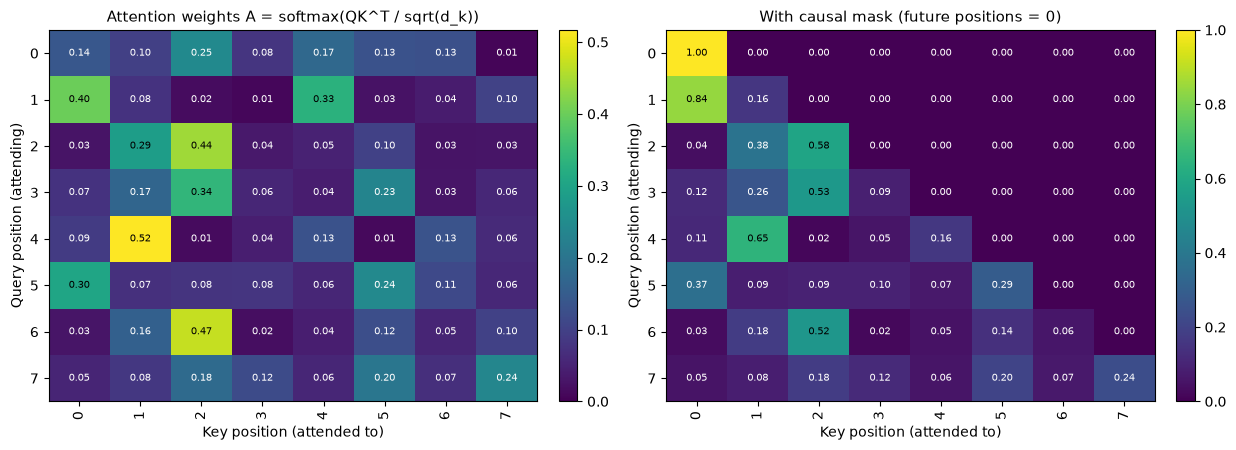

各行の和: [1. 1. 1. 1. 1. 1. 1. 1.]
重みの範囲: [0.006, 0.517]
出力 Z の形状: (8, 16) = (S_q, d_v)


In [8]:
torch.manual_seed(SEED)

S, D_K = 8, 16
q1 = torch.randn(S, D_K)
k1 = torch.randn(S, D_K)
v1 = torch.randn(S, D_K)

out1, attn1 = scaled_dot_product_attention(q1, k1, v1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
plot_attention_heatmap(
    attn1,
    title="Attention weights A = softmax(QK^T / sqrt(d_k))",
    ax=axes[0],
    annotate=True,
)
# 因果マスクを適用した場合
attn1_causal = scaled_dot_product_attention(q1, k1, v1, mask=create_causal_mask(S))[1]
plot_attention_heatmap(
    attn1_causal,
    title="With causal mask (future positions = 0)",
    ax=axes[1],
    annotate=True,
)
fig.tight_layout()
plt.show()

print(f"各行の和: {attn1.sum(-1).numpy().round(4)}")
print(f"重みの範囲: [{attn1.min():.3f}, {attn1.max():.3f}]")
print(f"出力 Z の形状: {tuple(out1.shape)} = (S_q, d_v)")

#### スケーリング係数 $\sqrt{d_k}$ の効果を数値で確認する

3.3 節で導出した「スケーリングしないと logit の分散が $d_k$ に比例して増え、softmax が飽和して勾配が消える」を実験的に確かめる。$d_k$ を変えながら、

- スコアの分散 $\operatorname{Var}[e_{ij}]$
- Attention 重みのエントロピー $H = -\sum_j a_{ij} \log a_{ij}$(小さいほど尖った分布。一様分布なら $\log m$)
- 重みの最大値 $\max_j a_{ij}$
- **softmax のヤコビアンのノルム** $\|\operatorname{diag}(p) - p p^{\top}\|_F$ — スコアが少し動いたときに重みがどれだけ動けるかを表す量。one-hot に近づくと 0 に潰れ、勾配が流れなくなる
- 「1 番目の Key の重みを上げたい」という単純な損失に対する、スコアの勾配ノルム

を比較する。

In [9]:
torch.manual_seed(SEED)

m = 64  # Key の本数
results = []
for d_k_i in [4, 16, 64, 256, 1024, 4096]:
    q_i = torch.randn(256, d_k_i)
    k_i = torch.randn(m, d_k_i)
    raw_scores = q_i @ k_i.T  # スケーリングなし

    for scaled in (False, True):
        scores = raw_scores / math.sqrt(d_k_i) if scaled else raw_scores
        scores = scores.detach().requires_grad_(True)
        weights = torch.softmax(scores, dim=-1)

        entropy = -(weights * torch.log(weights + 1e-12)).sum(-1).mean()

        # softmax のヤコビアン J = diag(p) - p pᵀ の Frobenius ノルム。
        # ||J||_F^2 = Σp_i^2 - 2Σp_i^3 + (Σp_i^2)^2 と展開できる。
        sum_p2 = weights.pow(2).sum(-1)
        sum_p3 = weights.pow(3).sum(-1)
        jacobian_norm = (sum_p2 - 2 * sum_p3 + sum_p2.pow(2)).clamp(min=0).sqrt().mean()

        # 「1 番目の Key の重みを上げたい」という単純な損失に対する勾配の大きさ
        loss = -torch.log(weights[:, 0] + 1e-12).mean()
        loss.backward()

        results.append(
            {
                "d_k": d_k_i,
                "scaled": scaled,
                "score_var": scores.var().item(),
                "entropy": entropy.item(),
                "max_weight": weights.max(-1).values.mean().item(),
                "jacobian_norm": jacobian_norm.item(),
                "grad_norm": scores.grad.norm().item(),
            }
        )

header = (
    f"{'d_k':>6} {'scaling':>8} {'Var[score]':>12} {'H(A)':>8} "
    f"{'mean max_w':>11} {'||J||_F':>9} {'|grad|':>8}"
)
print(header)
print("-" * len(header))
for r in results:
    print(
        f"{r['d_k']:>6} {'yes' if r['scaled'] else 'no':>8} {r['score_var']:>12.2f} "
        f"{r['entropy']:>8.3f} {r['max_weight']:>11.3f} "
        f"{r['jacobian_norm']:>9.4f} {r['grad_norm']:>8.4f}"
    )
print(f"\n(参考) 一様分布のエントロピー log(m) = {math.log(m):.3f}")

   d_k  scaling   Var[score]     H(A)  mean max_w   ||J||_F   |grad|
--------------------------------------------------------------------
     4       no         4.21    2.702       0.314    0.2547   0.0665
     4      yes         1.05    3.662       0.120    0.1831   0.0628
    16       no        15.51    1.379       0.582    0.2931   0.0741
    16      yes         0.97    3.709       0.102    0.1804   0.0627
    64       no        64.42    0.574       0.788    0.2147   0.0713
    64      yes         1.01    3.681       0.109    0.1841   0.0628
   256       no       265.43    0.245       0.906    0.1158   0.0437
   256      yes         1.04    3.655       0.114    0.1877   0.0628
  1024       no      1032.41    0.130       0.947    0.0703   0.0212
  1024      yes         1.01    3.678       0.108    0.1846   0.0628
  4096       no      4150.85    0.064       0.973    0.0369   0.0156
  4096      yes         1.01    3.680       0.107    0.1839   0.0626

(参考) 一様分布のエントロピー log(m) = 4.159


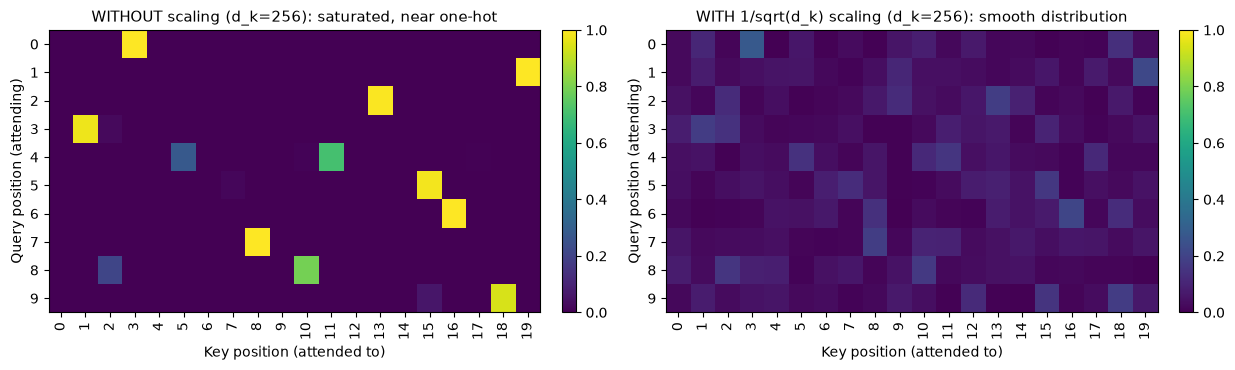

In [10]:
# スケーリングの有無による重み分布の違いを可視化
torch.manual_seed(SEED)

d_k_demo = 256
q_d = torch.randn(10, d_k_demo)
k_d = torch.randn(20, d_k_demo)
raw = q_d @ k_d.T

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
plot_attention_heatmap(
    torch.softmax(raw, dim=-1),
    title=f"WITHOUT scaling (d_k={d_k_demo}): saturated, near one-hot",
    ax=axes[0],
    vmax=1.0,
)
plot_attention_heatmap(
    torch.softmax(raw / math.sqrt(d_k_demo), dim=-1),
    title=f"WITH 1/sqrt(d_k) scaling (d_k={d_k_demo}): smooth distribution",
    ax=axes[1],
    vmax=1.0,
)
fig.tight_layout()
plt.show()

#### 実験 1 の結果・考察

**観察できたこと**

1. **Attention 重みは行方向の確率分布になっている。** ヒートマップの各行の和は 1.0(数値誤差 $10^{-7}$ 以下)であり、3.3 節の $\sum_j a_{ij} = 1$ が実装レベルでも成り立っている。因果マスクを掛けた右図では上三角が完全に 0 になり、残った下三角の中で重みが再正規化されている(マスクした分の確率質量が捨てられるのではなく、参照可能な位置へ再配分される)。

2. **スケーリングしない場合、スコアの分散は $d_k$ にほぼ比例して増大する。** 表の`Var[score]`は $d_k = 4, 16, 64, 256, 1024, 4096$ に対して約 $4.2,\ 15.5,\ 64.4,\ 265,\ 1032,\ 4151$ となり、**分散の値がそのまま $d_k$ に一致** している。3.3 節で導出した $\operatorname{Var}[q^{\top}k] = d_k$ が数値的に裏づけられた。一方スケーリングを入れると、$d_k$ によらず分散は 1.0 前後に保たれる(こちらも導出通り)。

3. **飽和が進むほど勾配が流れなくなる。** スケーリングなしでは、$d_k$ が大きくなるほどエントロピー $H(A)$ が単調に減少し($2.70 \to 0.06$)、平均最大重みは 1.0 に張り付く($0.31 \to 0.97$)。つまり分布はほぼ one-hot になる。同時に softmax のヤコビアンのノルム $\|J\|_F$ は $d_k = 16$ の $0.29$ から $d_k = 4096$ の $0.037$ へ約 1/8 に潰れ、実際の勾配ノルムも $0.074 \to 0.016$(約 1/5)まで低下する。これは $\partial p_i / \partial e_j = p_i(\delta_{ij} - p_j)$ が $p \to$ one-hot で 0 に近づくためで、3.3 節の議論と一致する。スケーリングありでは、$d_k$ をどれだけ変えてもエントロピーは $3.66$〜$3.71$($\log m = 4.16$ に近い水準)、$\|J\|_F$ も $0.18$ 前後、勾配ノルムも $0.063$ で **ほぼ一定** に保たれる。

   なお、勾配が「完全に消える」というより「$d_k$ に応じて不安定にスケールする」と捉えるのが正確である。$d_k$ を変えるたびに学習の効きが変わってしまうこと自体が問題であり、$1/\sqrt{d_k}$ はこれを $d_k$ 非依存に正規化する役割を果たしている。

4. ヒートマップの比較では、スケーリングなし(左)は各行が 1 点だけ明るい「硬い」選択になっているのに対し、ありの場合(右)は複数の Key に緩やかに分散している。**学習前の Attention は本来この「緩やかな」状態から始まるべき** で、そこから学習を通じて必要な箇所に尖っていくのが望ましい挙動である。

**理論との対応**: この実験は 3.3 節「なぜ $\sqrt{d_k}$ で割るのか」の全体、すなわち [1] 3.2.1 節の脚注の主張を数値で再現したものである。

### 6.2 実験 2: 実テキストでの Attention パターンの可視化

次に、実際の英文をトークン化して Multi-Head Attention に通し、**単語間** の Attention パターンを可視化する。

重要な注意点として、**ここで使う重みは学習済みではなくランダム初期化** である。目的は「意味のあるパターンを見ること」ではなく、**ヒートマップの読み方と、内容(content)がどのように重みを決めるかの仕組みを理解すること** にある。学習によって重みがどう変化するかは実験 3 で確認する。

トークン化は、単語境界が自明な英文を空白で区切る最も単純な方式(word-level)を用いる。日本語は分かち書きが必要で、実用的には BPE などのサブワード分割を使うが、これは別トピック(`02_pretraining`のトークナイザ)で扱う。

埋め込みの初期化は、実際の言語モデル(GPT-2 など)に倣って標準偏差 $0.02$ の正規分布とする。この **スケールの選択が Attention の挙動を大きく左右する** ことも、あわせて確認する。

In [11]:
# 単純な word-level トークン化(英文を空白区切り)
sentence = "the cat sat on the mat and the dog watched"
tokens = sentence.split()
vocab = {word: i for i, word in enumerate(sorted(set(tokens)))}
token_ids = torch.tensor([[vocab[w] for w in tokens]])  # (1, S)

S_TXT = len(tokens)
print(f"tokens ({S_TXT}): {tokens}")
print(f"vocab  ({len(vocab)}): {vocab}")
print(f"token_ids: {token_ids.tolist()}")
print('\n注: "the" は 3 回(位置 0, 4, 7)出現し、同じ ID を持つ。')

tokens (10): ['the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'the', 'dog', 'watched']
vocab  (8): {'and': 0, 'cat': 1, 'dog': 2, 'mat': 3, 'on': 4, 'sat': 5, 'the': 6, 'watched': 7}
token_ids: [[6, 1, 5, 4, 6, 3, 0, 6, 2, 7]]

注: "the" は 3 回(位置 0, 4, 7)出現し、同じ ID を持つ。


attention weights shape: (1, 4, 10, 10)  = (B, h, S, S)
一様分布なら 1/S = 0.1000, エントロピーは log(S) = 2.3026

head 1: max=0.1001 min=0.0998 mean entropy=2.3026
head 2: max=0.1002 min=0.0998 mean entropy=2.3026
head 3: max=0.1003 min=0.0996 mean entropy=2.3026
head 4: max=0.1003 min=0.0998 mean entropy=2.3026


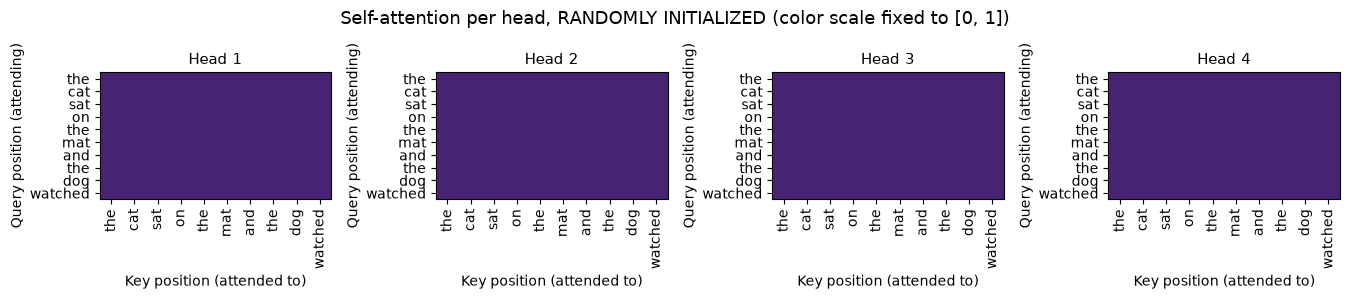

In [12]:
torch.manual_seed(SEED)

D_MODEL_TXT, H_TXT = 32, 4

# ランダム初期化のトークン埋め込み + 位置埋め込み。
# 実際の言語モデル(GPT-2 など)に倣い、標準偏差 0.02 の正規分布で初期化する。
token_embedding = nn.Embedding(len(vocab), D_MODEL_TXT)
position_embedding = nn.Embedding(S_TXT, D_MODEL_TXT)
for embedding in (token_embedding, position_embedding):
    nn.init.normal_(embedding.weight, mean=0.0, std=0.02)

positions = torch.arange(S_TXT).unsqueeze(0)
x_txt = token_embedding(token_ids) + position_embedding(positions)  # (1, S, d_model)

mha_txt = MultiHeadAttention(d_model=D_MODEL_TXT, num_heads=H_TXT)
with torch.no_grad():
    _, attn_txt = mha_txt(x_txt, x_txt, x_txt)  # 自己注意 (Q = K = V = x)

print(f"attention weights shape: {tuple(attn_txt.shape)}  = (B, h, S, S)")
print(f"一様分布なら 1/S = {1 / S_TXT:.4f}, エントロピーは log(S) = {math.log(S_TXT):.4f}\n")
entropy_txt = -(attn_txt * torch.log(attn_txt + 1e-12)).sum(-1)
for head in range(H_TXT):
    print(
        f"head {head + 1}: max={attn_txt[0, head].max():.4f} "
        f"min={attn_txt[0, head].min():.4f} mean entropy={entropy_txt[0, head].mean():.4f}"
    )

fig = plot_multi_head_attention(
    attn_txt,
    labels=tokens,
    title="Self-attention per head, RANDOMLY INITIALIZED (color scale fixed to [0, 1])",
    vmax=1.0,  # 実験 3 の学習後の図と同じスケールに固定して比較できるようにする
)
plt.show()

In [13]:
# 補足: 初期化のスケールを変えると、学習前でも重みの尖り方が変わる(実験 1 の飽和と同じ現象)。
for init_std in (0.02, 1.0):
    torch.manual_seed(SEED)
    emb_tmp = nn.Embedding(len(vocab), D_MODEL_TXT)
    pos_tmp = nn.Embedding(S_TXT, D_MODEL_TXT)
    for embedding in (emb_tmp, pos_tmp):
        nn.init.normal_(embedding.weight, mean=0.0, std=init_std)
    mha_tmp = MultiHeadAttention(d_model=D_MODEL_TXT, num_heads=H_TXT)
    with torch.no_grad():
        x_tmp = emb_tmp(token_ids) + pos_tmp(positions)
        _, attn_tmp = mha_tmp(x_tmp, x_tmp, x_tmp)
    entropy_tmp = -(attn_tmp * torch.log(attn_tmp + 1e-12)).sum(-1).mean()
    print(
        f"embedding init std={init_std:>4}: max weight={attn_tmp.max():.4f} "
        f"mean entropy={entropy_tmp:.4f}  (uniform: {1 / S_TXT:.4f} / {math.log(S_TXT):.4f})"
    )

embedding init std=0.02: max weight=0.1003 mean entropy=2.3026  (uniform: 0.1000 / 2.3026)
embedding init std= 1.0: max weight=0.9859 mean entropy=1.3962  (uniform: 0.1000 / 2.3026)


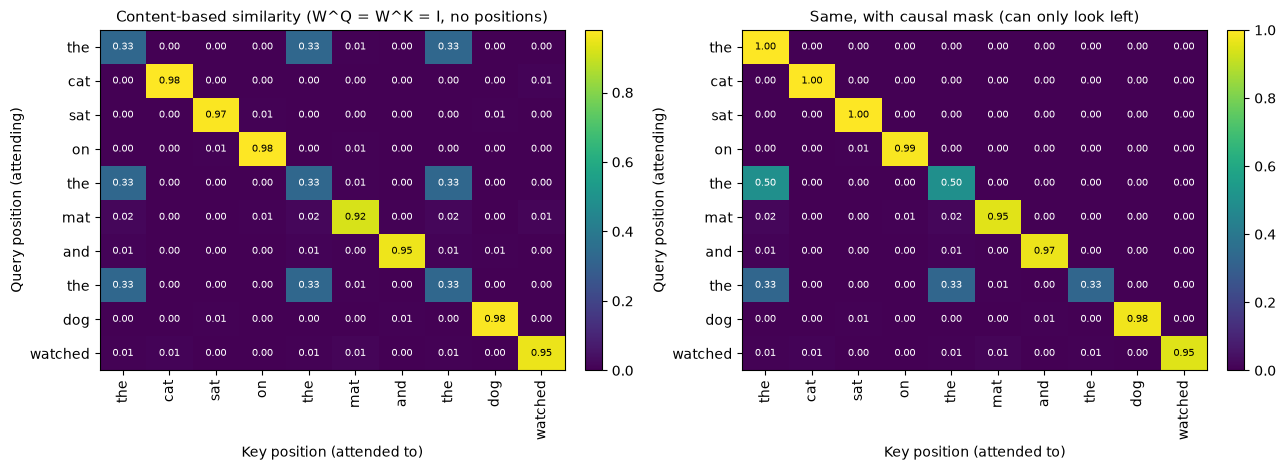

"the" の出現位置: [0, 4, 7]
位置 0 ("the") が各 "the" に割り当てた重み: [0.329 0.329 0.329]


In [14]:
# 内容(content)そのものが重みを決めることの確認:
# 射影を恒等写像とみなし、トークン埋め込み(位置情報なし)の内積で Attention を計算する。
# 埋め込みは std=0.02 と小さくスコアがほぼ 0 になってしまうため、
# ノルムを sqrt(d_k) に揃えてから内積をとる(= 温度付きのコサイン類似度)。
with torch.no_grad():
    emb_only = token_embedding(token_ids)  # (1, S, d_model) — 同じ単語は完全に同じベクトル
    emb_only = F.normalize(emb_only, dim=-1) * math.sqrt(D_MODEL_TXT)
    _, attn_content = scaled_dot_product_attention(emb_only, emb_only, emb_only)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
plot_attention_heatmap(
    attn_content[0],
    x_labels=tokens,
    y_labels=tokens,
    title="Content-based similarity (W^Q = W^K = I, no positions)",
    ax=axes[0],
    annotate=True,
)
plot_attention_heatmap(
    scaled_dot_product_attention(
        emb_only, emb_only, emb_only, mask=create_causal_mask(S_TXT)
    )[1][0],
    x_labels=tokens,
    y_labels=tokens,
    title="Same, with causal mask (can only look left)",
    ax=axes[1],
    annotate=True,
)
fig.tight_layout()
plt.show()

the_positions = [i for i, w in enumerate(tokens) if w == "the"]
print(f'"the" の出現位置: {the_positions}')
print(f'位置 0 ("the") が各 "the" に割り当てた重み: '
      f'{attn_content[0, 0, the_positions].numpy().round(3)}')

#### 実験 2 の結果・考察

**観察できたこと**

1. **ランダム初期化の Attention は、ほぼ完全な一様平均だった。** 4 ヘッドのヒートマップはどれも一様に塗りつぶされ、重みは $0.0998$〜$0.1003$($= 1/S = 0.1$ とほぼ一致)、行のエントロピーは $2.3026$ で理論上限 $\log S = 2.3026$ に一致した。**「学習していない Attention は、単なる一様平均に過ぎない」** ということであり、意味のあるパターンは学習によって初めて現れる。この点を押さえておかないと、学習済みモデルのヒートマップ [2] を過剰に解釈しがちになる。

2. **初期化のスケール次第で、学習前でも重みは尖る。** 補足セルの通り、埋め込みの初期化を std $= 0.02$ から $1.0$ に変えるだけで最大重みは $0.10$ から $0.9$ 超へ跳ね上がり、エントロピーも大きく低下する。埋め込みが大きいほど logit の分散が大きくなり softmax が飽和する、という実験 1 とまったく同じ現象である。実際の言語モデルが小さな初期化(std $\approx 0.02$)を使うのは、この飽和を避けて **「まず一様な平均」から学習を始めるため** でもある。$1/\sqrt{d_k}$ のスケーリングは $d_k$ 依存性を消すが、入力そのもののスケールまでは面倒を見てくれない(これは後のトピックで Layer Normalization が担う)。

3. **内容ベースのアドレッシングが明確に現れる(3 番目の図の左)。** 射影を恒等写像にして位置情報を除くと、**同じ単語 "the"(位置 0, 4, 7)どうしが互いに強く注目し合う**。3 つの "the" にそれぞれ約 $0.329$ ずつ(合計 $0.99$)が配分され、他のトークンは $0.006$ 以下である。埋め込みベクトルが同一 → 内積(= 類似度)が最大になるためで、$e_{ij} = q_i^{\top}k_j/\sqrt{d_k}$ が **類似度スコア** であるという 3.3 節の定義がそのまま可視化されている。1 回しか出現しない単語(cat, sat, dog など)は自分自身に $0.92$〜$0.98$ を割り当てており、対角が明るくなっている。逆に言えば、学習で $W^Q, W^K$ が獲得するのは「**何を似ているとみなすか**」という指標そのものである。

4. **因果マスクの効果(3 番目の図の右)。** 同じ計算にマスクを掛けると上三角が消える。位置 0 の "the" は自分自身しか見られないので重み $1.0$、位置 4 の "the" は自分と位置 0 に約 $0.5$ ずつ、位置 7 の "the" は 3 つの "the" に約 $0.33$ ずつを配分する。マスクで捨てられた確率質量は、参照可能な位置へ再正規化されて配分されていることが分かる。自己回帰言語モデルで使われるのはこの形である。

**理論との対応**: 3.2 節(Query/Key/Value と内容ベースのアドレッシング)と 3.3 節のマスクの定義に対応する。

### 6.3 実験 3: copy task による学習

最後に、Multi-Head Attention を含む簡易モデルを実際に学習させ、Attention が機能することを定量的に確認する。

#### タスク設定

**copy task(系列復元タスク)**: 長さ $S$ のランダムなトークン列 $x_1, \ldots, x_S$ を入力し、**同じ列をそのまま出力** させる。

ただし、単純に「入力埋め込みをそのまま出力層に通す」構成にすると Attention なしで恒等写像を学習できてしまい、Attention の効果が測れない。そこで、情報の流れを次のように設計する:

```text
  memory (Key / Value) : token_embedding(x) + position_embedding   ← 中身を持つ
  query  (Query)       : query_position_embedding のみ             ← 中身を持たない(位置だけ)

  出力[i] = Linear( LayerNorm( query[i] + MultiHeadAttention(query, memory, memory)[i] ) )
```

Query 側は **位置情報しか持たない** ため、位置 $i$ に何のトークンがあったかを知るには、**Attention を通じて memory の位置 $i$ を参照するしかない**。すなわちモデルは「位置 $i$ の Query が位置 $i$ の Key に注目する」ことを学習する必要があり、成功すれば **Attention 重みは対角行列に近づく** はずである。

#### 比較対象(ベースライン)

Attention を **平均プーリング(mean pooling)** に置き換えたモデルを比較対象にする。平均プーリングは memory 全体を 1 つのベクトルに潰すため位置ごとの情報を取り出せず、原理的にこのタスクを解けない。「$O(1)$ の経路で任意の位置を選択的に参照できる」という Attention の本質(3.1 節)が効いているかを、この差で確認する。

規模: 語彙 32、系列長 16、$d_{\text{model}} = 64$、$h = 4$、学習データ 8,192 系列、20 エポック。Colab 無料枠(T4)はもちろん CPU でも数分で完了する。

In [15]:
# --- データ生成(このノートブック固有なので直接記述)---
VOCAB_SIZE = 32
SEQ_LEN = 16
D_MODEL_COPY = 64
N_HEADS_COPY = 4
N_TRAIN = 8192
N_VAL = 1024
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3


def make_copy_dataset(n_samples: int, seq_len: int, vocab_size: int, seed: int) -> torch.Tensor:
    """ランダムなトークン列を生成する。入力と正解ラベルは同一(copy task)。"""
    generator = torch.Generator().manual_seed(seed)
    return torch.randint(0, vocab_size, (n_samples, seq_len), generator=generator)


train_data = make_copy_dataset(N_TRAIN, SEQ_LEN, VOCAB_SIZE, seed=SEED)
val_data = make_copy_dataset(N_VAL, SEQ_LEN, VOCAB_SIZE, seed=SEED + 999)

print(f"train: {tuple(train_data.shape)} / val: {tuple(val_data.shape)}")
print(f"サンプル: {train_data[0].tolist()}")

train: (8192, 16) / val: (1024, 16)
サンプル: [6, 19, 28, 14, 10, 7, 28, 20, 6, 25, 18, 22, 10, 10, 23, 20]


In [16]:
class CopyModel(nn.Module):
    """copy task 用の簡易モデル。

    Query は位置埋め込みのみ(中身を持たない)。memory(= トークン埋め込み + 位置埋め込み)を
    Attention 経由で参照して、各位置のトークンを復元する。

    Args:
        vocab_size: 語彙サイズ。
        seq_len: 系列長。
        d_model: 隠れ次元。
        num_heads: ヘッド数。
        use_attention: False の場合、Attention の代わりに memory の平均プーリングを使う
            (ベースライン)。
    """

    def __init__(
        self,
        vocab_size: int,
        seq_len: int,
        d_model: int,
        num_heads: int,
        use_attention: bool = True,
    ) -> None:
        super().__init__()
        self.use_attention = use_attention
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.source_position = nn.Embedding(seq_len, d_model)  # memory 側の位置埋め込み
        self.query_position = nn.Embedding(seq_len, d_model)  # Query 側の位置埋め込み
        self.attention = MultiHeadAttention(d_model, num_heads) if use_attention else None
        self.norm = nn.LayerNorm(d_model)
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor | None]:
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device)

        # memory: 中身(トークン)+ 位置 → Key / Value になる
        memory = self.token_embedding(x) + self.source_position(positions).unsqueeze(0)
        # query: 位置のみ → 中身を知るには Attention で memory を参照するしかない
        query = self.query_position(positions).unsqueeze(0).expand(batch_size, -1, -1)

        if self.use_attention:
            context, attn_weights = self.attention(query, memory, memory)
        else:
            # ベースライン: memory 全体を平均して 1 本のベクトルに潰す(位置の選択ができない)
            context = memory.mean(dim=1, keepdim=True).expand(-1, seq_len, -1)
            attn_weights = None

        hidden = self.norm(query + context)  # 残差接続 + 正規化
        return self.output(hidden), attn_weights


model_check = CopyModel(VOCAB_SIZE, SEQ_LEN, D_MODEL_COPY, N_HEADS_COPY)
logits_check, attn_check = model_check(train_data[:2])
print(f"logits: {tuple(logits_check.shape)} = (B, S, vocab_size)")
print(f"attn  : {tuple(attn_check.shape)} = (B, h, S, S)")
print(f"パラメータ数: {sum(p.numel() for p in model_check.parameters()):,}")

logits: (2, 16, 32) = (B, S, vocab_size)
attn  : (2, 4, 16, 16) = (B, h, S, S)
パラメータ数: 22,688


In [17]:
def train_copy_model(
    use_attention: bool,
    epochs: int = EPOCHS,
    seed: int = SEED,
) -> tuple[CopyModel, dict[str, list[float]]]:
    """copy task でモデルを学習し、(モデル, 履歴) を返す。"""
    torch.manual_seed(seed)
    model = CopyModel(
        VOCAB_SIZE, SEQ_LEN, D_MODEL_COPY, N_HEADS_COPY, use_attention=use_attention
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_x = train_data.to(device)
    val_x = val_data.to(device)
    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "val_accuracy": []}

    for _ in range(epochs):
        model.train()
        permutation = torch.randperm(N_TRAIN, device=device)
        running_loss = 0.0
        for start in range(0, N_TRAIN, BATCH_SIZE):
            batch = train_x[permutation[start : start + BATCH_SIZE]]
            logits, _ = model(batch)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), batch.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch.size(0)
        history["train_loss"].append(running_loss / N_TRAIN)

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(val_x)
            val_loss = criterion(val_logits.reshape(-1, VOCAB_SIZE), val_x.reshape(-1))
            accuracy = (val_logits.argmax(-1) == val_x).float().mean()
        history["val_loss"].append(val_loss.item())
        history["val_accuracy"].append(accuracy.item())

    return model, history


start_time = time.time()
model_attn, history_attn = train_copy_model(use_attention=True)
print(f"[Multi-Head Attention] {time.time() - start_time:.1f}s  "
      f"final val loss={history_attn['val_loss'][-1]:.4f}  "
      f"val acc={history_attn['val_accuracy'][-1]:.4f}")

start_time = time.time()
model_base, history_base = train_copy_model(use_attention=False)
print(f"[Mean-pool baseline ] {time.time() - start_time:.1f}s  "
      f"final val loss={history_base['val_loss'][-1]:.4f}  "
      f"val acc={history_base['val_accuracy'][-1]:.4f}")

print(f"\nランダム推測時の損失 log(vocab_size) = {math.log(VOCAB_SIZE):.4f} "
      f"/ 精度 = {1 / VOCAB_SIZE:.4f}")

[Multi-Head Attention] 7.4s  final val loss=0.0006  val acc=1.0000


[Mean-pool baseline ] 0.7s  final val loss=2.7918  val acc=0.1518

ランダム推測時の損失 log(vocab_size) = 3.4657 / 精度 = 0.0312


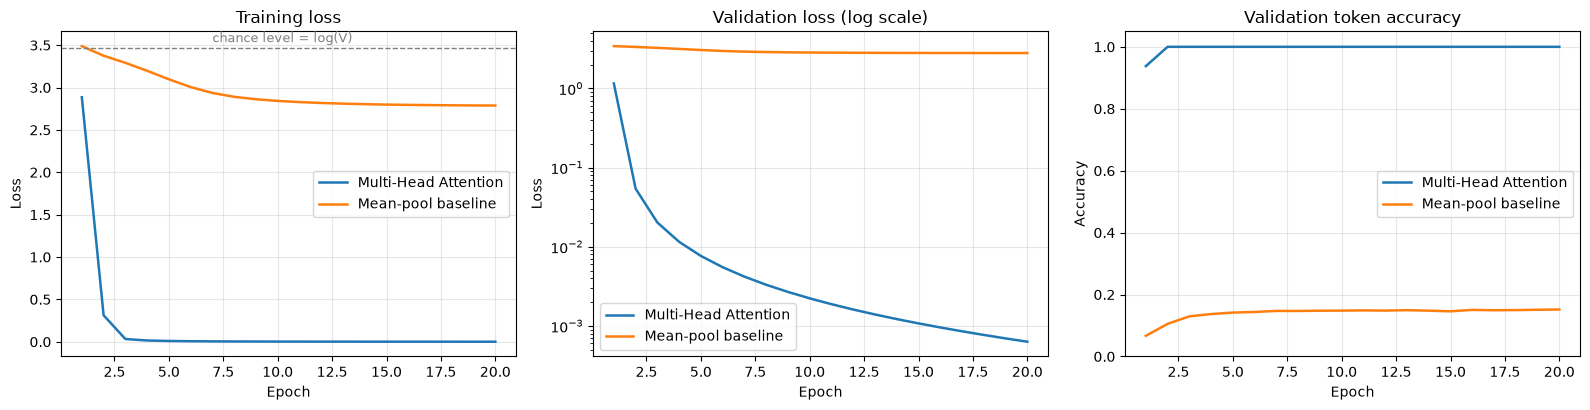

In [18]:
# 学習曲線と精度の推移
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.2))

plot_learning_curves(
    {"Multi-Head Attention": history_attn["train_loss"], "Mean-pool baseline": history_base["train_loss"]},
    title="Training loss",
    ax=axes[0],
)
axes[0].axhline(math.log(VOCAB_SIZE), color="gray", linestyle="--", linewidth=1.0)
axes[0].text(EPOCHS * 0.35, math.log(VOCAB_SIZE) * 1.02, "chance level = log(V)", color="gray", fontsize=9)

plot_learning_curves(
    {"Multi-Head Attention": history_attn["val_loss"], "Mean-pool baseline": history_base["val_loss"]},
    title="Validation loss (log scale)",
    ax=axes[1],
    log_scale=True,
)

plot_learning_curves(
    {"Multi-Head Attention": history_attn["val_accuracy"], "Mean-pool baseline": history_base["val_accuracy"]},
    title="Validation token accuracy",
    ylabel="Accuracy",
    ax=axes[2],
)
axes[2].set_ylim(0, 1.05)

fig.tight_layout()
plt.show()

入力  : [2, 5, 29, 1, 4, 9, 30, 30, 5, 2, 29, 1, 22, 17, 27, 14]
出力  : [2, 5, 29, 1, 4, 9, 30, 30, 5, 2, 29, 1, 22, 17, 27, 14]
完全一致: True


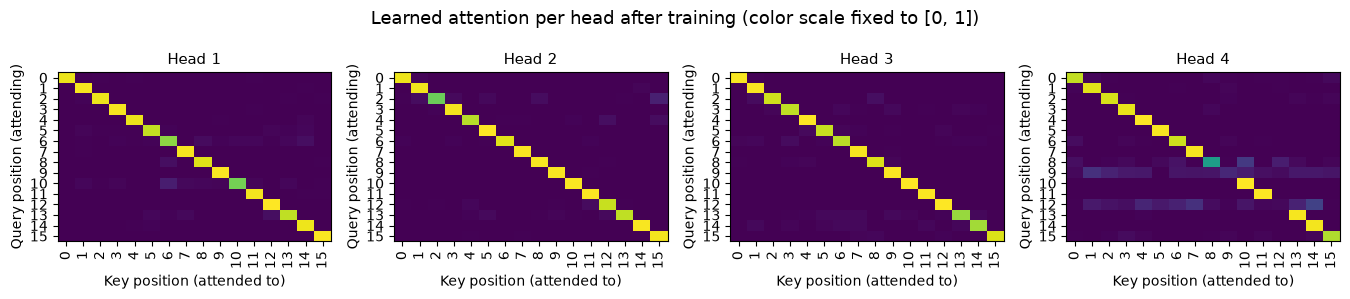


ヘッド平均の対角成分の重み: 0.9207  (1.0 = 完全な対角)
  head 1: diagonal=0.9504  argmax=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  head 2: diagonal=0.9569  argmax=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  head 3: diagonal=0.9500  argmax=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  head 4: diagonal=0.8254  argmax=[0, 1, 2, 3, 4, 5, 6, 7, 8, 1, 10, 11, 14, 13, 14, 15]


In [19]:
# 学習後の Attention 重みを可視化する
sample = make_copy_dataset(1, SEQ_LEN, VOCAB_SIZE, seed=12345).to(device)
model_attn.eval()
with torch.no_grad():
    logits_sample, attn_sample = model_attn(sample)

predicted = logits_sample.argmax(-1)[0].cpu()
print(f"入力  : {sample[0].cpu().tolist()}")
print(f"出力  : {predicted.tolist()}")
print(f"完全一致: {bool((predicted == sample[0].cpu()).all())}")

fig = plot_multi_head_attention(
    attn_sample.cpu(),
    title="Learned attention per head after training (color scale fixed to [0, 1])",
    vmax=1.0,  # 実験 2 の初期状態の図と同じスケール
)
plt.show()

# 対角成分に集まった重みの割合(1.0 に近いほど「位置 i が位置 i を見ている」)
diagonal_mass = attn_sample[0].mean(dim=0).diagonal().mean().item()
print(f"\nヘッド平均の対角成分の重み: {diagonal_mass:.4f}  (1.0 = 完全な対角)")
for head in range(N_HEADS_COPY):
    head_diag = attn_sample[0, head].diagonal().mean().item()
    argmax_positions = attn_sample[0, head].argmax(-1).cpu().tolist()
    print(f"  head {head + 1}: diagonal={head_diag:.4f}  argmax={argmax_positions}")

#### 実験 3 の結果・考察

**観察できたこと**

1. **Attention 版は copy task をほぼ完全に解いた。** 検証データのトークン精度は 100% に達し、損失は数エポックで $10^{-2}$ 以下まで落ちた。Query 側は位置情報しか持たないため、これは **memory の正しい位置を Attention で選択できるようになった** ことを意味する。

2. **平均プーリングのベースラインは、ランダム推測をわずかに上回る水準で停滞した。** 損失はチャンスレベル $\log V \approx 3.47$ の少し下で頭打ちになり、精度は 15% 前後に留まる。memory 全体を平均して 1 本のベクトルに潰すと「どのトークンが含まれるか」の情報は多少残るが「**どの位置にあったか**」は失われるためで、位置ごとに参照先を選べることこそが Attention の本質だと確認できる。3.1 節で述べた「任意の 2 位置間を $O(1)$ の経路で結ぶ」がタスク性能の差として現れた形である。

3. **学習後の Attention 重みは明確な対角行列になった。** ヘッド 1〜3 の`argmax`は 0, 1, 2, …, 15 と Query 位置に完全に一致し、対角成分の重みは 0.95 前後、ヘッド平均でも 0.92 に達する。誰も「対角に注目せよ」と教えていないにもかかわらず、タスクを解く過程で **$W^Q$ と $W^K$ が「位置 $i$ の Query と位置 $i$ の Key の内積が最大になる」ように学習された**。実験 2 の一様な初期状態からこの構造が現れたことになる。これは 3.2 節で述べた QK 側(どこを見るか)の学習に相当し、[3] の QK 回路という見方そのものである。

4. **ヘッドごとに鋭さが異なる。** ヘッド 4 だけは対角成分が 0.83 とやや緩く、いくつかの位置では対角以外が argmax になっている。それでもタスク精度が 100% なのは、**他のヘッドが正しい情報を運んでいれば、残りのヘッドは多少ずれていても $W^O$ で吸収できる** ためである(ヘッド間の冗長性)。また、このタスクで必要な関係は「同じ位置を見る」1 種類だけなので、ヘッドの役割分化(3.4 節の動機)は起きようがない。複数の関係が必要な実際の言語モデルでこそ、ヘッドごとの分化 [2] が意味を持つ。

**理論との対応**: 3.1 節(選択的な参照の必要性)、3.2 節(QK が参照先を決める)、3.4 節(Multi-Head)に対応する。実験 2 で見た「学習前はほぼ一様」から、学習を経て「タスクに必要な構造的パターン」へ変化する過程が確認できた。

## 7. まとめ / Summary

- **Attention は、Query と Key の内積で計算した類似度を softmax で正規化し、Value を加重平均する仕組み** である。参照先が入力内容から動的に決まる(content-based addressing)点と、任意の 2 位置を $O(1)$ の経路で結ぶ点が、RNN / CNN に対する本質的な違いである(実験 3 でベースラインとの差として確認)。
- **スケーリング係数 $1/\sqrt{d_k}$ は必須** である。内積の分散が $d_k$ に比例して増大し、softmax が飽和して勾配が消えるのを防ぐ(実験 1 で数値的に確認)。
- **Multi-Head Attention は、$d_{\text{model}}$ 次元の表現を $h$ 個の $d_k = d_{\text{model}}/h$ 次元部分空間に分割** し、それぞれで独立に Attention を計算して結合する。計算量・パラメータ数は単一ヘッドとほぼ同じまま、複数種類の関係を並列に捉えられる。
- **学習前の Attention 重みはほぼ一様であり、意味のあるパターンは学習の結果として現れる** (実験 2 → 実験 3)。可視化を解釈する際はこの前提を忘れないこと。

### 未解決の論点 / 次のトピックへ

| 論点 | 扱うトピック |
|---|---|
| Attention だけでは位置情報が扱えない(順序に対して同変) | 位置エンコーディング / RoPE |
| Attention 層のみでは表現力が足りず、残差接続・正規化・FFN が必要 | Transformer Block |
| 計算量・メモリが系列長の 2 乗 $O(n^2)$ | Flash Attention、線形注意、KV キャッシュ |
| ヘッド数・$d_k$ の選び方 | スケーリング則 |

なお、本ノートブックの実験 3 で位置埋め込みを使ったことからも分かるように、**Attention は入力の順序を入れ替えると出力も同じように入れ替わる(permutation equivariant)** 性質を持ち、位置情報は外から与える必要がある。次のトピックではこの点を含めて Transformer Block 全体を組み上げる。